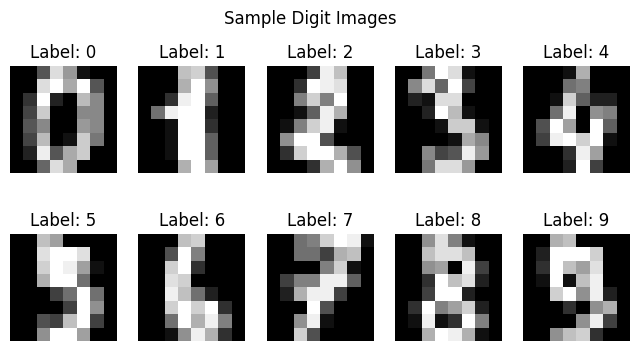

Accuracy: 0.825

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.94      0.95        33
           1       0.57      0.75      0.65        28
           2       0.88      0.64      0.74        33
           3       0.88      0.82      0.85        34
           4       0.84      0.83      0.84        46
           5       0.93      0.85      0.89        47
           6       0.89      0.94      0.92        35
           7       0.89      0.91      0.90        34
           8       0.59      0.73      0.66        30
           9       0.84      0.80      0.82        40

    accuracy                           0.82       360
   macro avg       0.83      0.82      0.82       360
weighted avg       0.84      0.82      0.83       360



In [4]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


digits = load_digits()
X = digits.data
y = digits.target

plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Label: {digits.target[i]}")
    plt.axis('off')
plt.suptitle("Sample Digit Images")
plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

base_estimator = DecisionTreeClassifier(max_depth=1)

# AdaBoost model
model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))